In [2]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load some data
with open("data/league-fixture/big_fixture_data.json") as file:
    data = json.load(file)

In [4]:
last_season_data = data["2023-2024"]
df = pd.DataFrame()
for k, v in last_season_data.items():
    v = pd.DataFrame.from_dict(v)
    v["league"] = k
    df = pd.concat([df, v])

df.reset_index(drop=True, inplace=True)
df.head()

,Wk,Day,Date,Time,Home,Away,xG,xG.1,Score,Attendance,...,t2_clearances,t1_offsides,t2_offsides,t1_goal_kicks,t2_goal_kicks,t1_throw_ins,t2_throw_ins,t1_long_balls,t2_long_balls,league
0,1.0,Fri,2023-08-11,20:00,Burnley,Manchester City,0.3,1.9,0–3,21572.0,...,7.0,0.0,1.0,5.0,7.0,15.0,13.0,65.0,77.0,Premier-League
1,1.0,Sat,2023-08-12,12:30,Arsenal,Nott'ham Forest,0.8,1.2,2–1,59984.0,...,18.0,2.0,1.0,8.0,5.0,18.0,9.0,38.0,54.0,Premier-League
2,1.0,Sat,2023-08-12,15:00,Everton,Fulham,2.7,1.5,0–1,39940.0,...,31.0,6.0,3.0,9.0,7.0,27.0,22.0,76.0,53.0,Premier-League
3,1.0,Sat,2023-08-12,15:00,Brighton,Luton Town,4.0,1.5,4–1,31872.0,...,28.0,2.0,3.0,8.0,11.0,16.0,11.0,42.0,73.0,Premier-League
4,1.0,Sat,2023-08-12,15:00,Sheffield Utd,Crystal Palace,0.5,1.9,0–1,31194.0,...,16.0,2.0,2.0,10.0,6.0,18.0,31.0,81.0,72.0,Premier-League


In [5]:
df.groupby("league").size()

league
Bundesliga        306
La-Liga           380
Ligue-1           306
Premier-League    380
Serie-A           380
dtype: int64

In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 53 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Wk                1748 non-null   float64
 1   Day               1748 non-null   object 
 2   Date              1748 non-null   object 
 3   Time              1748 non-null   object 
 4   Home              1748 non-null   object 
 5   Away              1748 non-null   object 
 6   xG                1748 non-null   float64
 7   xG.1              1748 non-null   float64
 8   Score             1748 non-null   object 
 9   Attendance        1748 non-null   float64
 10  Referee           1748 non-null   object 
 11  season            1748 non-null   object 
 12  t1_captain        1751 non-null   object 
 13  t2_captain        1751 non-null   object 
 14  t1_formation      1751 non-null   object 
 15  t2_formation      1751 non-null   object 
 16  t1_possession     1751 non-null   object 


In [7]:
# I want to look into the leagues that have the least amount of goals scored
# I will add a column of the total goals scored in a game
df.dropna(subset=["Score"], inplace=True)
df["home_goals"] = df["Score"].str[0]
df["away_goals"] = df["Score"].str[-1]
df = df.astype({"home_goals": "int32", "away_goals": "int32"})
df.dtypes

Wk                  float64
Day                  object
Date                 object
Time                 object
Home                 object
Away                 object
xG                  float64
xG.1                float64
Score                object
Attendance          float64
Referee              object
season               object
t1_captain           object
t2_captain           object
t1_formation         object
t2_formation         object
t1_possession        object
t2_possession        object
t1_passing           object
t2_passing           object
t1_shots             object
t2_shots             object
t1_saves             object
t2_saves             object
t1_yellow_cards     float64
t1_red_cards        float64
t2_yellow_cards     float64
t2_red_cards        float64
t1_fouls            float64
t2_fouls            float64
t1_corners          float64
t2_corners          float64
t1_crosses          float64
t2_crosses          float64
t1_touches          float64
t2_touches          

In [8]:
# Find out the total number of goals per game.
df.groupby("league")[["home_goals", "away_goals"]].sum().sum(axis=1) / df.groupby("league").size()

league
Bundesliga        3.218954
La-Liga           2.644737
Ligue-1           2.697368
Premier-League    3.278947
Serie-A           2.597884
dtype: float64

In [9]:
# Gather the workflow into a function to be able to do this for every season of interest.
def goals_per_game(season):
    season_data = data[season]
    df = pd.DataFrame()
    for k, v in season_data.items():
        v = pd.DataFrame.from_dict(v)
        v["league"] = k
        df = pd.concat([df, v])

    df.reset_index(drop=True, inplace=True)
    df.dropna(subset=["Score"], inplace=True)
    df["home_goals"] = df["Score"].str[0]
    df["away_goals"] = df["Score"].str[-1]
    df = df.astype({"home_goals": "int32", "away_goals": "int32"})
    table = df.groupby("league")[["home_goals", "away_goals"]].sum().sum(axis=1) / df.groupby("league").size()
    table = table.to_frame()
    table.columns = [season]

    return(table)

In [10]:
seasons = ["2017-2018", "2018-2019", "2019-2020", "2020-2021", "2021-2022", "2022-2023", "2023-2024", "2024-2025"]
leagues = [
        {"id": "9", "name": "Premier-League"}, {"id": "12", "name": "La-Liga"},
        {"id": "11", "name": "Serie-A"}, {"id": "13", "name": "Ligue-1"}, {"id": "20", "name": "Bundesliga"}
    ]
leagues = [l["name"] for l in leagues]
# Make sure the number of games is around 380
for season in seasons:
    for league in leagues:
        df = pd.DataFrame.from_dict(data[season][league])
        if len(df) < 370:
            print(season, league)
            print(len(df))


2017-2018 Bundesliga
306
2018-2019 Bundesliga
306
2019-2020 La-Liga
269
2019-2020 Serie-A
250
2019-2020 Ligue-1
278
2019-2020 Bundesliga
223
2020-2021 Bundesliga
308
2021-2022 Bundesliga
308
2022-2023 Bundesliga
308
2023-2024 Ligue-1
306
2023-2024 Bundesliga
306
2024-2025 Premier-League
286
2024-2025 La-Liga
271
2024-2025 Ligue-1
153
2024-2025 Bundesliga
223


In [11]:
# Return the average number of goals scored per game for the past 8 seasons
gpg_df = pd.DataFrame()
for season in range(len(seasons)):
    gpg_df = pd.concat([gpg_df, goals_per_game(seasons[season])], axis=1)

<Axes: xlabel='None', ylabel='Bundesliga'>

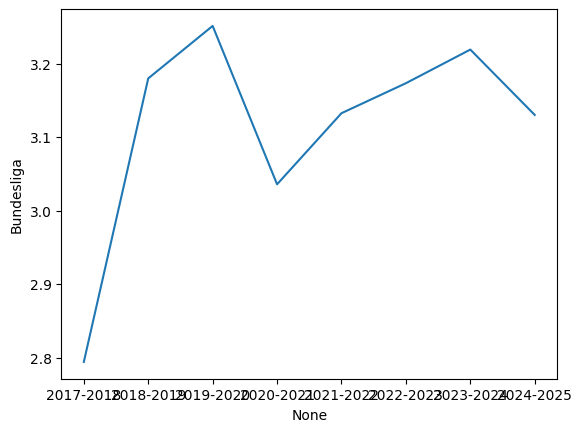

In [12]:
sns.lineplot(x=gpg_df.columns, y = gpg_df.iloc[0, :])

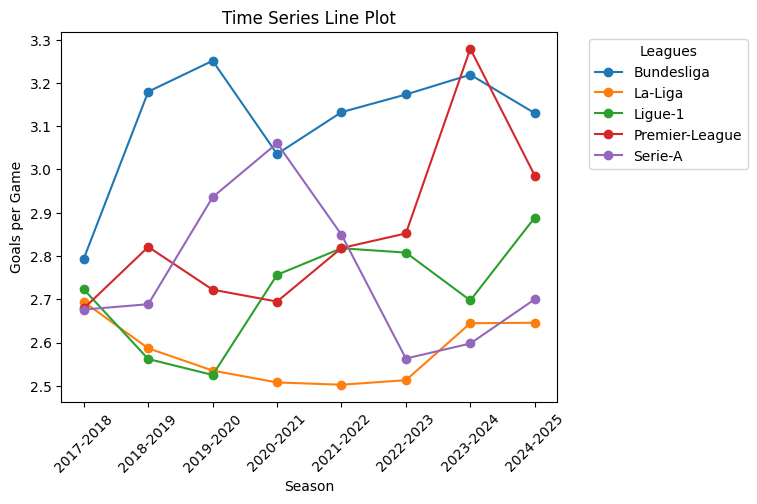

In [13]:
gpg_df.T.plot(marker="o")
plt.title('Time Series Line Plot')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.ylabel('Goals per Game')
plt.legend(title='Leagues', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.show()

            league     season  goals_per_game
0       Bundesliga  2017-2018        2.794118
1          La-Liga  2017-2018        2.693931
2          Ligue-1  2017-2018        2.722955
3   Premier-League  2017-2018        2.678947
4          Serie-A  2017-2018        2.676316
5       Bundesliga  2018-2019        3.179739
6          La-Liga  2018-2019        2.586842
7          Ligue-1  2018-2019        2.562005
8   Premier-League  2018-2019        2.821053
9          Serie-A  2018-2019        2.688654
10      Bundesliga  2019-2020        3.251121
11         La-Liga  2019-2020        2.535316
12         Ligue-1  2019-2020        2.525180
13  Premier-League  2019-2020        2.722222
14         Serie-A  2019-2020        2.936000
15      Bundesliga  2020-2021        3.035714
16         La-Liga  2020-2021        2.507895
17         Ligue-1  2020-2021        2.756545
18  Premier-League  2020-2021        2.694737
19         Serie-A  2020-2021        3.060526
20      Bundesliga  2021-2022     

<Axes: xlabel='season', ylabel='goals_per_game'>

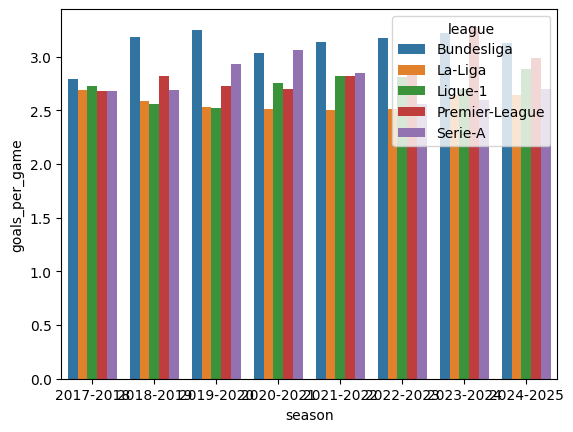

In [29]:
# Cluster bar chart
# I have to restructure the table to work with seaborn.
df = pd.melt(gpg_df.reset_index(),
            id_vars=[gpg_df.index.name], var_name="season", value_name="goals_per_game")
print(df)
sns.barplot(data=df, x="season", y="goals_per_game", hue="league")

In [26]:
gpg_df.reset_index()

,league,2017-2018,2018-2019,2019-2020,2020-2021,2021-2022,2022-2023,2023-2024,2024-2025
0,Bundesliga,2.794118,3.179739,3.251121,3.035714,3.132404,3.173203,3.218954,3.130045
1,La-Liga,2.693931,2.586842,2.535316,2.507895,2.502632,2.513158,2.644737,2.645756
2,Ligue-1,2.722955,2.562005,2.525180,2.756545,2.817935,2.807895,2.697368,2.888889
3,Premier-League,2.678947,2.821053,2.722222,2.694737,2.818421,2.852243,3.278947,2.986014
4,Serie-A,2.676316,2.688654,2.936000,3.060526,2.849206,2.563158,2.597884,2.700000
